# Prepare validation data set Narrabeen

In [1]:
path = '/home/jovyan/data/98_paper2_kf_dtm/03_Narrabeen_validation_data/'

## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import geopandas as gpd
import numpy as np
from shapely import Point

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from coastal_data import CD_geometry, CD_visualisation

/home/jovyan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
data_orig = pd.read_csv(path + 'Narrabeen_Profiles.csv')
data_orig

,Site,Profile ID,Date,Chainage,Elevation,Flag
0,NARRA,PF6,1976-04-27,0,6.29,EMERY
1,NARRA,PF6,1976-04-27,10,1.68,EMERY
2,NARRA,PF6,1976-04-27,20,0.10,EMERY
3,NARRA,PF6,1976-04-27,30,-0.95,EMERY
4,NARRA,PF4,1976-04-27,0,9.52,EMERY
...,...,...,...,...,...,...
158583,NARRA,PF4,2019-11-27,113,-0.82,GPS
158584,NARRA,PF4,2019-11-27,114,-0.82,GPS
158585,NARRA,PF4,2019-11-27,115,-0.85,GPS
158586,NARRA,PF4,2019-11-27,116,-0.91,GPS


In [4]:
np.unique(data_orig['Profile ID'])

array(['PF1', 'PF2', 'PF4', 'PF6', 'PF8'], dtype=object)

## Coordinates PF1

In [5]:
def deg360_to_decimal(deg, minute, sec):
    '''
    Convert degrees given in deg, minute, seconds to decimal degrees.
    '''
    deci = np.abs(deg) + minute/60 + sec/3600
    if np.sign(deg) == -1:
        deci = -deci
    return deci

In [6]:
# Origin and orientation of each profile
# from data description paper table 3
lat_orig_pf1 = deg360_to_decimal(-33, 42, 20.65)
lon_orig_pf1 = deg360_to_decimal(151, 18, 16.30)
orientation_pf1 = 118.42 # degree North

lat_orig_pf2 = deg360_to_decimal(-33, 42, 33.45)
lon_orig_pf2 = deg360_to_decimal(151, 18, 10.33)
orientation_pf2 = 113.36

lat_orig_pf4 = deg360_to_decimal(-33, 43, 1.55)
lon_orig_pf4 = deg360_to_decimal(151, 17, 58.84)
orientation_pf4 = 100.26

lat_orig_pf6 = deg360_to_decimal(-33, 43, 29.81)
lon_orig_pf6 = deg360_to_decimal(151, 17, 58.65)
orientation_pf6 = 83.65

lat_orig_pf8 = deg360_to_decimal(-33, 43, 55.94)
lon_orig_pf8 = deg360_to_decimal(151, 18, 6.47)
orientation_pf8 = 60.48

In [7]:
# Initialise GeoDataFrame with the avaialable information
data_gdf = gpd.GeoDataFrame(columns=['profile', 'date', 'elev', 'coords'], geometry='coords')
data_gdf.date = pd.to_datetime(data_orig['Date'])
data_gdf.elev = data_orig['Elevation']
data_gdf.profile = data_orig['Profile ID']
data_gdf = data_gdf.set_crs('4326')

In [8]:
# Get coordinates from start point, orientation and chainage
def get_profile_coordinates(profile, lat_orig, lon_orig, orientation):
    idx_pf, = np.where(data_gdf.profile == profile)
    chains = data_orig.loc[idx_pf,'Chainage']
    dists = CD_geometry.dist_meter_to_dist_deg(chains)

    lats, lons = CD_geometry.dist_angle_to_coords((lat_orig, lon_orig), dists, orientation/180*np.pi)

    data_gdf.loc[idx_pf, 'coords'] = gpd.points_from_xy(lons, lats)

get_profile_coordinates('PF1', lat_orig_pf1, lon_orig_pf1, orientation_pf1)
get_profile_coordinates('PF2', lat_orig_pf2, lon_orig_pf2, orientation_pf2)
get_profile_coordinates('PF4', lat_orig_pf4, lon_orig_pf4, orientation_pf4)
get_profile_coordinates('PF6', lat_orig_pf6, lon_orig_pf6, orientation_pf6)
get_profile_coordinates('PF8', lat_orig_pf8, lon_orig_pf8, orientation_pf8)

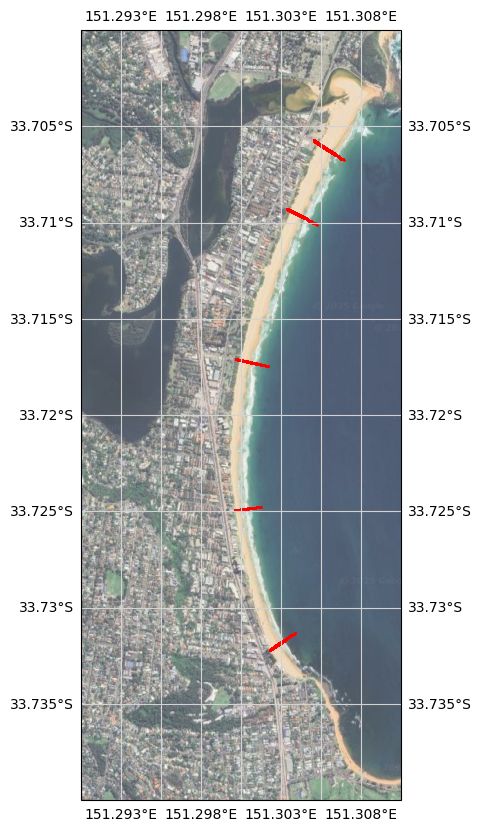

In [9]:
extent = [151.29, 151.31, -33.74, -33.70]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)
ax.scatter(data_gdf.geometry.x, data_gdf.geometry.y, transform=ccrs.PlateCarree(), s=1, c='red')

In [10]:
data_gdf.to_file(path + 'narrabeen_profiles_with_coords.geojson')